# Nevergrad comparison

Used for comparing Nevergrad optimisers.  Since CMA-ES was selected can also run for different locations, values of sigma and locations.

In [1]:
import nevergrad as ng
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

from modules.helper_functions_tsp import (
        find_problem_size, 
        find_distances_array,
        cost_fn_fact,
        bind_weights,
        vqc_circuit,
        define_parameters,
        create_initial_rotations,
        find_sdk,
        find_local_quantum,
        calculate_hot_start_data,
        find_optimiser_function,
        find_nevergrad_optimizers,
        )

from modules.helper_functions_nevergrad import (
        validate_sigma_list,
        ng_cost_function_fact,
        )       

from modules.quantum_circuits import print_quantum_circuits

from classes.MyDataLogger import MyDataLogger, MySubDataLogger

from modules.config import SLICES

SIGMA_LIST = [0.7]
ITERATIONS_LIST = [1_250]
CYCLES = 1
LOCATION_LIST = [6]

CMA_ONLY = True        #only use CMA-ES rather than a complete scan
PRINT_CIRCUITS = False  

if CMA_ONLY:           #set plot graph size 
    N_ROWS, N_COLS = 1, 1 
else:           
    N_ROWS, N_COLS = 3, 3

In [2]:
def validate_optimisers_dict(optimisers_dict):
    graph_grid_size = N_ROWS * N_COLS
    if len(optimisers_dict) != graph_grid_size:
        raise ValueError(f'{len(optimisers_dict)} optimisers found, but {graph_grid_size} needed for the graph grid size of {N_ROWS} by {N_COLS}.')

SubDataLogger instantiated.  Run ID = 20260612-15-25-26 - 15-25-26
 Running notebook for sdl.target='local_qiskit', sdl.aws=False, sdk_type='qiskit'
 with sdl.mps=True, sdl.slice=1.0,
There are 8 logical qubits needed for 6 locations in the original formulation.
Running mode 2 with 1024 shots
Reading distance data
Data will be read from filename networks\sim_dist_6_locs.txt.
It is known that the shortest distance is 241.0
Number of parameters to be optimized is 16
After measurement, the following qubits are measured [0, 1, 2, 3, 4, 5, 6, 7]
The initial parameters (weights) are [5.54998    3.00137795 4.09309139 5.69873591 2.02456477 0.4147601
 6.16756783 0.27845668 5.85905924 1.92053296 2.58366163 4.89147514
 2.74949828 3.5857456  4.83195046 3.54537585]
Running with only CMA as the optimiser.
Run number 1 out of 1
SubDataLogger instantiated.  Run ID = 20260612-15-25-26 - 15-25-27
The time taken to run the code is 58.44 seconds
Saving data to results\results.csv
Detailed data for Run ID:

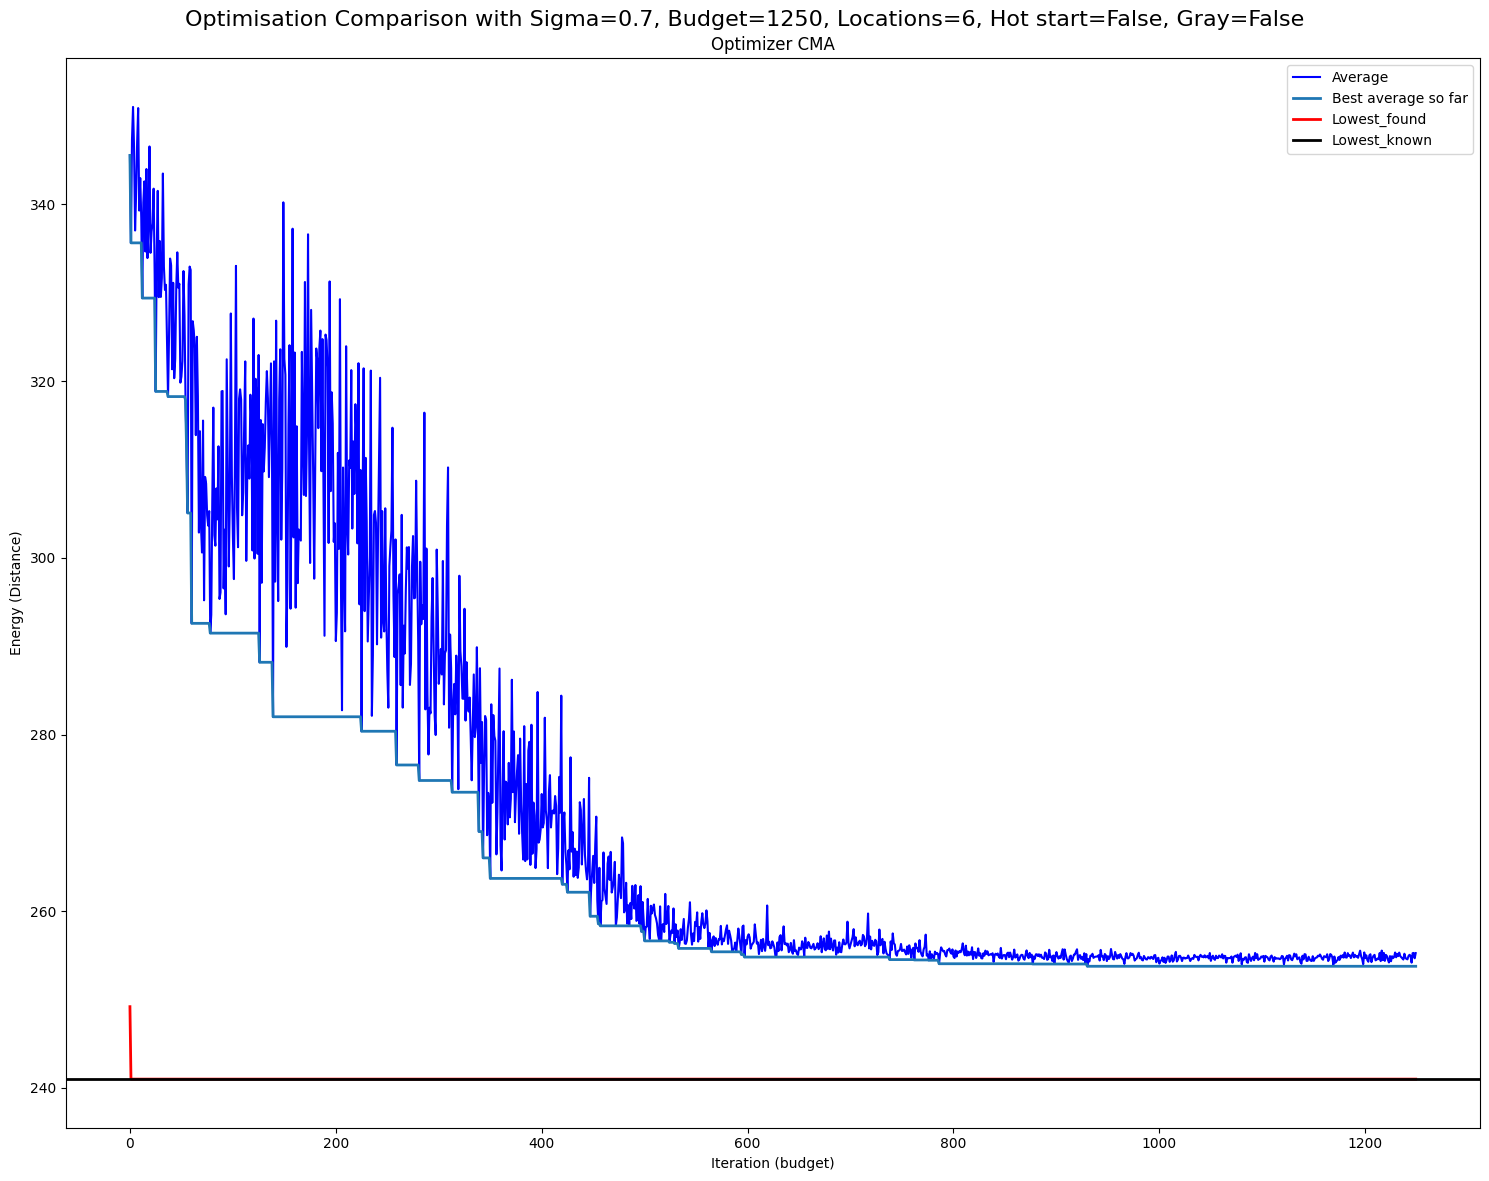

In [3]:
for locations in LOCATION_LIST:
    # Set up datalogger and sub-datalogger.  
    # No results are logged against this first datalogger, which sets up the quantum circuit.
    datalogger = MyDataLogger()
    sdl = MySubDataLogger(runid = datalogger.runid)
    sdl.update_general_constants_from_config()
    sdl.update_quantum_constants_from_config()
    sdl.validate_input()
    # Check that there are not multiple slices read from the parameter file.
    if len(SLICES) != 1:
        raise ValueError(f'{SLICES=} should only contain one value for this notebook, {len(SLICES)} found.') 
    slice = SLICES[0]
    sdl.slice = slice
    sdl.locations = locations
    #validate target and print out relevant information about the run.
    if not find_local_quantum(sdl.target):
        raise Exception(f'Notebook is only written for AWS or Qiskit to be run locally and {sdl.target=}')
    sdk_type = find_sdk(sdl.target)
    print(f' Running notebook for {sdl.target=}, {sdl.aws=}, {sdk_type=}')
    print(f' with {sdl.mps=}, {sdl.slice=},')
    #Find number of qubits and set up distance array.
    np.random.seed(42)
    sdl.qubits = find_problem_size(
        locations=sdl.locations,
        formulation=sdl.formulation
    )
    qubits = sdl.qubits
    print(f'There are {sdl.qubits} logical qubits needed for {sdl.locations} locations in the {sdl.formulation} formulation.')
    print(f'Running mode {sdl.mode} with {sdl.shots} shots')

    distance_array, best_dist = find_distances_array(sdl.locations, print_comments=True)
    #Set up and print quantum circuit.
    num_params = sdl.calculate_parameter_numbers()
    print(f'Number of parameters to be optimized is {num_params}')
    params = define_parameters(
        mode=sdl.mode,
        num_params=num_params,
        target=sdl.target,
        )
    qc = vqc_circuit(
        qubits=sdl.qubits,
        mode=sdl.mode,
        noise_bool=sdl.noise,
        layers=sdl.layers,
        params=params,
        target=sdl.target,
        )
    filename = Path.joinpath(datalogger.graph_sub_path, f'initial_unbound_circuit{sdl.mode}.pdf')
    if PRINT_CIRCUITS:
        print_quantum_circuits(
            qubits=sdl.qubits,
            sdk_type=sdk_type,
            qc=qc,
            filename=filename, 
            )
    # Set up the cost_fn using the factory.  This takes a bit string and returns a distance.
    cost_fn = cost_fn_fact(
        locations=sdl.locations,
        qubits=sdl.qubits,
        gray=sdl.gray,
        formulation=sdl.formulation,
        distance_array=distance_array,
        target=sdl.target
        )
    # Set up the initial parameters, either from the hot start, or from random, 
    # bind to the quantum circuit, and print out if the circuit is small.
    bin_hot_start_list=[]
    if sdl.hot_start:
        match sdk_type:
            case 'aws':
                raise Exception(f'The hot start list cannot be run at the moment with AWS circuits.  {sdl.hot_start=}')
            case 'qiskit':
                bin_hot_start_list, hot_start_distance = calculate_hot_start_data(
                    sdl=sdl, 
                    distance_array=distance_array,
                    cost_fn=cost_fn,
                    print_results=True,
                    )
            case '_':
                raise Exception(f'{sdk_type=} is not defined.')

    init_rots = create_initial_rotations(
        qubits=sdl.qubits,
        num_params=num_params,
        target=sdl.target,
        hot_start=sdl.hot_start,
        bin_hot_start_list=bin_hot_start_list,
        )

    print(f'The initial parameters (weights) are {init_rots}')
    bc = bind_weights(
        params=params, 
        rots=init_rots, 
        qc=qc,
        target=sdl.target,
        )
    filename = Path.joinpath(datalogger.graph_sub_path, f'initial_bound_circuit{sdl.mode}.pdf')

    if PRINT_CIRCUITS:
        print_quantum_circuits(
            qubits=sdl.qubits,
            sdk_type=sdk_type,
            qc=bc,
            filename=filename
            )
        
    ng_cost_function =  ng_cost_function_fact(
        qc=qc,
        target=sdl.target,
        noise_bool=sdl.noise,
        shots=sdl.shots,
        cost_fn=cost_fn,
        mps=sdl.mps,
        params=params,
        init_rots=init_rots,
        )

    cost = ng_cost_function(init_rots)
    if CMA_ONLY:
        print('Running with only CMA as the optimiser.')
        nevergrad_optimizers_dict = {
            'CMA': 
                {'source': 'nevergrad',
                'function': ng.optimizers.CMA,
                }
        }   
    else:
        nevergrad_optimizers_dict = find_nevergrad_optimizers()
    validate_optimisers_dict(nevergrad_optimizers_dict)
    validate_sigma_list(SIGMA_LIST)
    #Loop round parameters of interest, print out and save graphs and results.
    for iterations in ITERATIONS_LIST:    
        for count in range(CYCLES):
            print(f'Run number {count+1} out of {CYCLES}')
            for sigma in SIGMA_LIST:    
                instrum = ng.p.Instrumentation(
                ng.p.Array(shape=(num_params,))
                    .set_mutation(sigma=sigma)
                )
                fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 12))
                axes = np.atleast_1d(axes).flatten() # makes indexing easier
                title = (
                    f'Optimisation Comparison with Sigma={sigma}, '
                    f'Budget={iterations}, Locations={sdl.locations}, '
                    f'Hot start={sdl.hot_start}, Gray={sdl.gray}'
                )
                filepath = Path(datalogger.graph_sub_path).joinpath(f"{title} Run {count+1}.pdf")
                fig.suptitle(
                    title,
                    fontsize=16
                )
                for idx, optimizer_name in enumerate(nevergrad_optimizers_dict):
                    ax = axes[idx]  # select subplot
                    time.sleep(1)  # slight delay to ensure different SDL instances have different timestamps for their runid
                    t0 = time.time()
                    #need new sub data logger for each run
                    sdl = MySubDataLogger(runid = datalogger.runid)
                    sdl.update_general_constants_from_config()
                    sdl.update_quantum_constants_from_config()
                    sdl.validate_input()
                    sdl.num_params = num_params
                    sdl.slice = slice
                    sdl.iterations = iterations
                    sdl.locations = locations
                    sdl.qubits = qubits
                    sdl.sigma = sigma
                    if sdl.hot_start:
                        sdl.hot_start_dist = hot_start_distance
                    else:
                        sdl.hot_start_dist = 'n/a'
                    optimzer_function = find_optimiser_function(optimizer_name)
                    optimizer = optimzer_function(
                        parametrization=instrum,
                        budget=sdl.iterations,
                    )    
                    sdl.average_list, sdl_lowest_list, sdl.best_av_list = [], [], []
                    sdl.index_list = [i for i in range(sdl.iterations)]

                    best_av_to_date = float('inf')
                    best_dist_found  = float('inf')

                    for i in range(optimizer.budget):
                        candidate = optimizer.ask()
                        x = candidate.args[0]
                        value, lowest = ng_cost_function(x)
                        optimizer.tell(candidate, value)
                        sdl.average_list.append(value)
                        best_av_to_date= min(best_av_to_date,value)
                        best_dist_found = min(best_dist_found,lowest)
                        sdl.best_av_list.append(best_av_to_date)
                        sdl.lowest_list.append(best_dist_found)
                    
                    #prepare sub-graph
                    ax.plot(sdl.average_list, color='blue', label='Average', )
                    ax.plot(sdl.best_av_list, label='Best average so far', linewidth=2)
                    ax.plot(sdl.lowest_list, color='red', linewidth=2 ,label='Lowest_found')
                    ax.axhline(best_dist, color='black', linewidth=2, label='Lowest_known')
                    ax.set_xlabel('Iteration (budget)')
                    ax.set_ylabel('Energy (Distance)')
                    ax.legend()
                    title = str(f'Optimizer {optimizer_name}')
                    ax.set_title(title)

                    #update and save sub-data logger details
                    t1 = time.time()
                    elapsed = t1-t0
                    print(f'The time taken to run the code is {elapsed:.2f} seconds')
                    sdl.elapsed = elapsed

                    sdl.last_av = value
                    sdl.best_dist_found=best_dist_found
                    sdl.best_dist = best_dist
                    sdl.best_av_to_date = best_av_to_date
                    sdl.gradient_type = optimizer_name
                    sdl.update_cache_statistics(cost_fn)
                    sdl.save_results_to_csv()
                    sdl.save_detailed_results()

                #plot main graph, with sub-plots by optimiser
                plt.subplots_adjust(hspace=0.4, wspace=0.3)
                plt.tight_layout()
                print(f'Saving graph to {filepath}')
                plt.savefig(filepath)
                plt.show()